# Cheatsheet H6

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

In [2]:
penguins = sns.load_dataset('penguins') # Load the Palmer Penguins demo dataset
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


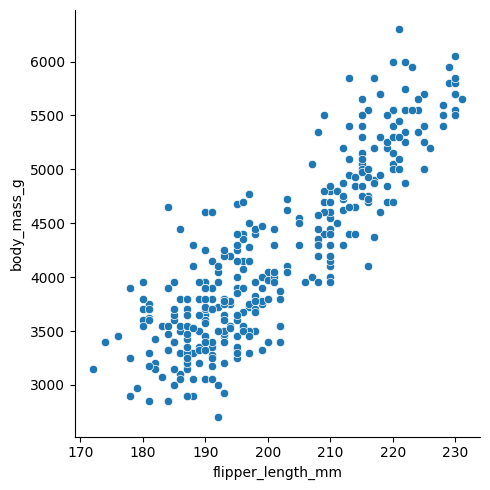

In [3]:
# Draw a scatterplot
sns.relplot(data=penguins,  x='flipper_length_mm', y='body_mass_g')

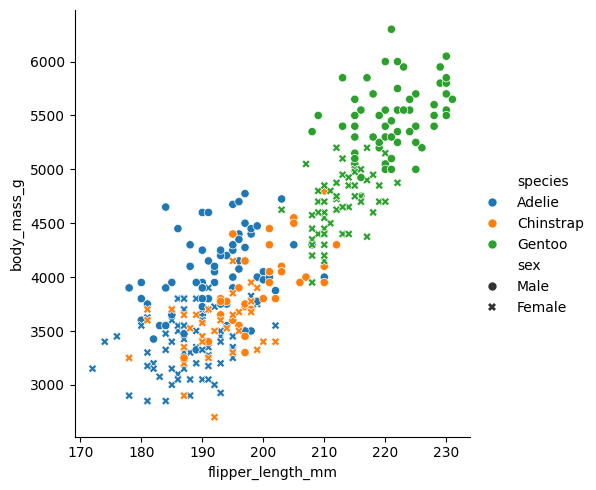

In [4]:
# More variation
sns.relplot(data=penguins,
            x='flipper_length_mm', y='body_mass_g', 
            hue='species', style='sex');

In [5]:
male_chinstrap = penguins[(penguins['species'] == 'Chinstrap') & (penguins['sex'] == 'Male')].groupby('flipper_length_mm')['body_mass_g'].mean().reset_index()

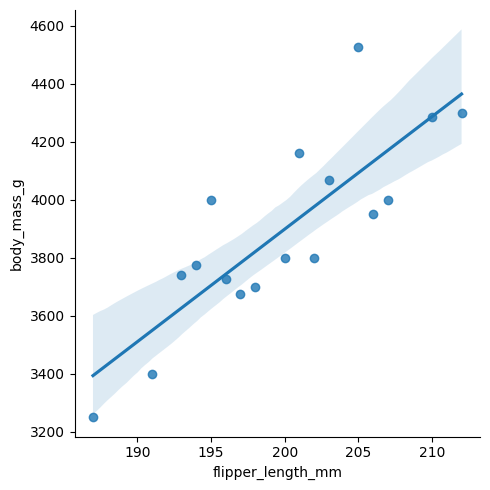

In [6]:
sns.lmplot(data=male_chinstrap, x='flipper_length_mm', y='body_mass_g')

In [10]:
# Calculate Beta_0 and Beta_1
b1, b0 = np.polyfit(x=male_chinstrap.flipper_length_mm, y=male_chinstrap.body_mass_g, deg=1)
print(f"Beta_0 = {b0:.5f}")
print(f"Beta_1 = {b1:.5f}")
print(f"Regression line: ŷ = {b0} + {b1}x")

Beta_0 = -3868.33204
Beta_1 = 38.83230
Regression line: ŷ = -3868.332037325039 + 38.83229652669778x


In [12]:
# Covariance
cov = np.cov(
    male_chinstrap.flipper_length_mm,
    male_chinstrap.body_mass_g,
    ddof=1)[0][1]
print(f"Covariance: {cov:.5f}")

Covariance: 1835.96814


In [13]:
cor = np.corrcoef(
    male_chinstrap.flipper_length_mm,
    male_chinstrap.body_mass_g)[0][1]
print(f"R ≈ {cor:.4f}")

R ≈ 0.8268


In [14]:
deter = cor ** 2
print(f"R² ≈ {deter:.4f}")

R² ≈ 0.6836


Depending on the value of $|R|$ (or $R^2$), you can draw a conclusion about the strength of the linear relation between the two variables:

| $abs(R)$  |  $R^2$   | Explained variance |   Linear relation    |
| :-------: | :------: | :----------------: | :------------------: |
|   < .3    |   < .1   |       < 10%        |      very weak       |
|  .3 - .5  | .1 - .25 |     10% - 25%      |         weak         |
|  .5 - .7  | .25 - .5 |     25% - 50%      |       moderate       |
| .7 - .85  | .5 - .75 |     50% - 75%      |        strong        |
| .85 - .95 | .75 - .9 |     75% - 90%      |     very strong      |
|   > .95   |   > .9   |       > 90%        | exceptionally strong |

### Conclusion

> increasing and x linear relation  
> decreasing and x linear relation  
> R² ~ y -> y% of de variance of de dependent variable can be explained by the independant variable